<a href="https://colab.research.google.com/github/np03cs4a240319-eng/draft/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/hour.csv")

print(df.head())
print(df.info())
print(df.describe())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 

In [ ]:
print(df.isnull().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [ ]:
# Drop non useful columns
df = df.drop(['instant','dteday','casual','registered'], axis=1)

# Check duplicates
print("Duplicates:", df.duplicated().sum())

# Remove outliers using IQR
Q1 = df['cnt'].quantile(0.25)
Q3 = df['cnt'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['cnt'] >= Q1-1.5*IQR) & (df['cnt'] <= Q3+1.5*IQR)]


Duplicates: 2


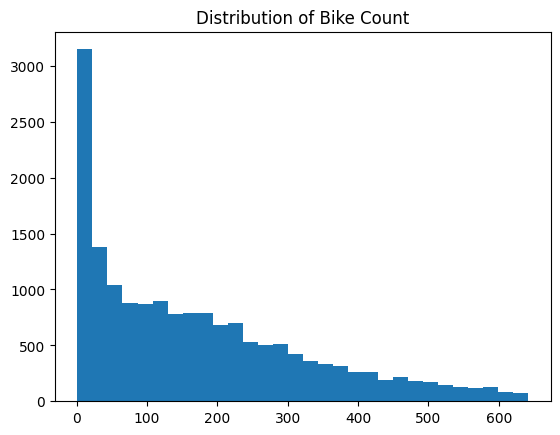

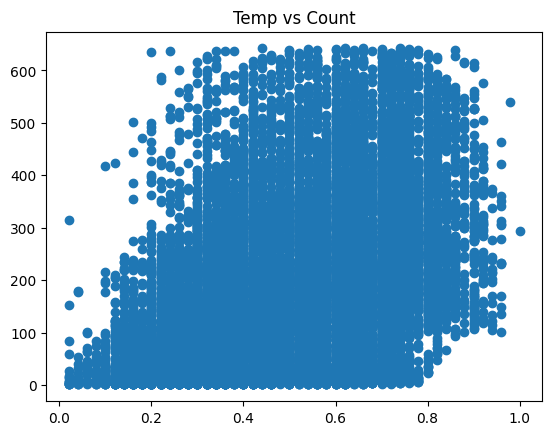

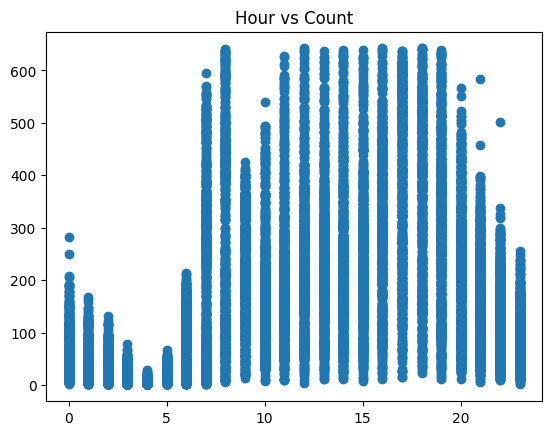

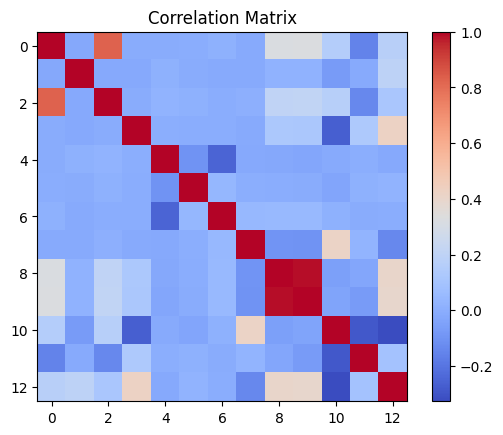

In [ ]:
# Distribution
plt.figure()
plt.hist(df['cnt'], bins=30)
plt.title("Distribution of Bike Count")
plt.show()

# Temp vs Count
plt.figure()
plt.scatter(df['temp'], df['cnt'])
plt.title("Temp vs Count")
plt.show()

# Hour vs Count
plt.figure()
plt.scatter(df['hr'], df['cnt'])
plt.title("Hour vs Count")
plt.show()

# Correlation
plt.figure()
plt.imshow(df.corr(), cmap='coolwarm')
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('cnt', axis=1)
y = df['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

nn = MLPRegressor(
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    max_iter=200
)

nn.fit(X_train, y_train)

pred_nn = nn.predict(X_test)

print("NN RMSE:", np.sqrt(mean_squared_error(y_test,pred_nn)))
print("NN R2:", r2_score(y_test,pred_nn))


NN RMSE: 50.26135259803884
NN R2: 0.8915672968574679


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("LR RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))


LR RMSE: 119.6075118682772


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))


RF RMSE: 37.68927311096593


In [ ]:
from sklearn.model_selection import GridSearchCV

param = {
    'n_estimators':[50,100],
    'max_depth':[5,10]
}

rf_grid = GridSearchCV(RandomForestRegressor(), param, cv=5)
rf_grid.fit(X_train, y_train)

print("Best Params:", rf_grid.best_params_)
print("CV Score:", rf_grid.best_score_)


Best Params: {'max_depth': 10, 'n_estimators': 100}
CV Score: 0.9002096365574372


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(f_regression, k=8)

Xf_train = selector.fit_transform(X_train, y_train)
Xf_test = selector.transform(X_test)

print("Selected Features:", selector.get_support())


Selected Features: [ True  True  True  True False False False  True  True  True  True False]


In [ ]:
final_rf = RandomForestRegressor(**rf_grid.best_params_)
final_rf.fit(Xf_train, y_train)

final_pred = final_rf.predict(Xf_test)

rmse = np.sqrt(mean_squared_error(y_test, final_pred))
r2 = r2_score(y_test, final_pred)
mae = mean_absolute_error(y_test, final_pred)


In [ ]:
results = pd.DataFrame({
"Model":["Linear Regression","Random Forest","Final RF"],
"MAE":[
    mean_absolute_error(y_test, lr_pred),
    mean_absolute_error(y_test, rf_pred),
    mae
],
"RMSE":[
    np.sqrt(mean_squared_error(y_test, lr_pred)),
    np.sqrt(mean_squared_error(y_test, rf_pred)),
    rmse
],
"R2":[
    r2_score(y_test, lr_pred),
    r2_score(y_test, rf_pred),
    r2
],
"CV Score":["-","-", rf_grid.best_score_]
})

print(results)


               Model        MAE        RMSE        R2 CV Score
0  Linear Regression  90.901396  119.607512  0.385943        -
1      Random Forest  23.988693   37.689273  0.939028        -
2           Final RF  52.007379   75.149039  0.757597  0.90021
